In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/StudentsPerformance.csv")

# Show first rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [17]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

In [20]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [21]:
df.dtypes

gender                           str
race/ethnicity                   str
parental_level_of_education      str
lunch                            str
test_preparation_course          str
math_score                     int64
reading_score                  int64
writing_score                  int64
dtype: object

In [22]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]

In [23]:
df["average_score"] = df["total_score"] / 3

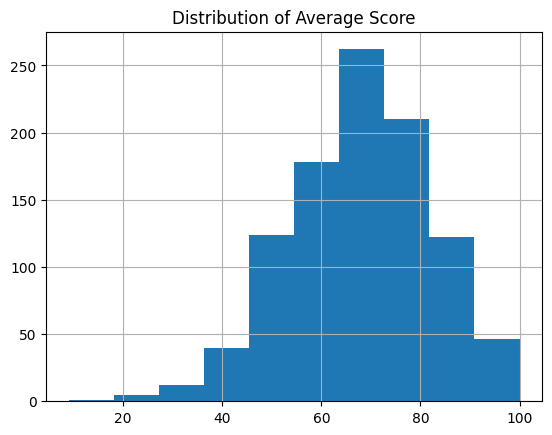

In [24]:
import matplotlib.pyplot as plt

df["average_score"].hist()
plt.title("Distribution of Average Score")
plt.show()

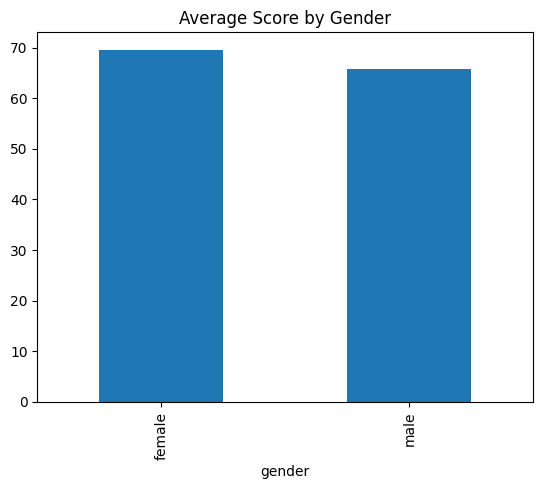

In [25]:
df.groupby("gender")["average_score"].mean().plot(kind="bar")
plt.title("Average Score by Gender")
plt.show()

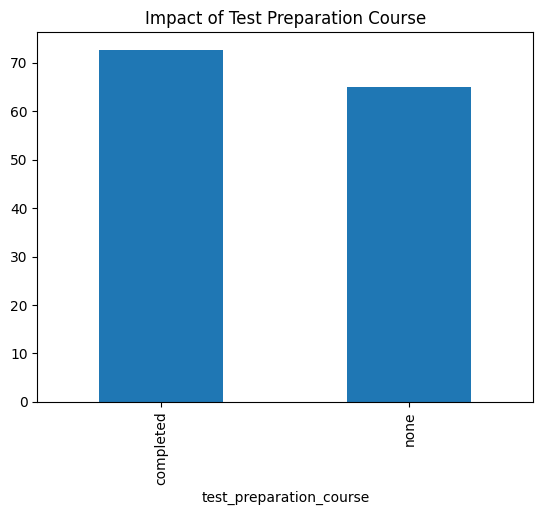

In [26]:
df.groupby("test_preparation_course")["average_score"].mean().plot(kind="bar")
plt.title("Impact of Test Preparation Course")
plt.show()

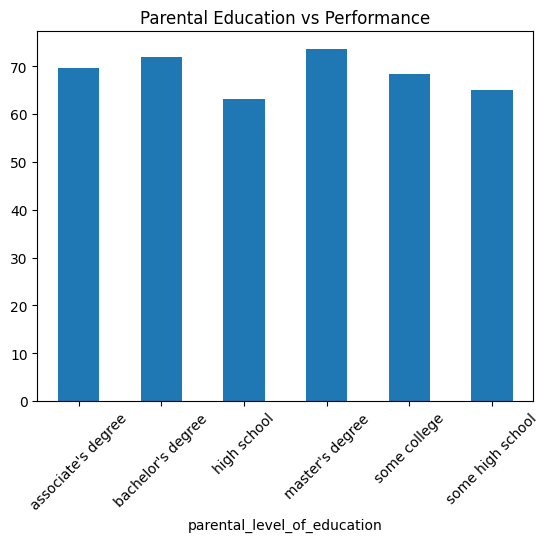

In [27]:
df.groupby("parental_level_of_education")["average_score"].mean().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Parental Education vs Performance")
plt.show()

In [28]:
df.groupby("parental_level_of_education")["average_score"].mean().sort_values()

parental_level_of_education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64

## Insights

1. Students who completed test preparation performed better.
2. Parental education has a moderate impact on scores.
3. Score distribution shows most students fall in mid-range.

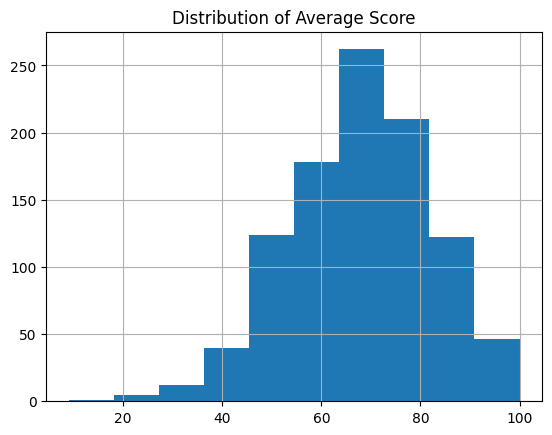

In [29]:
df["average_score"].hist()
plt.title("Distribution of Average Score")
plt.show()

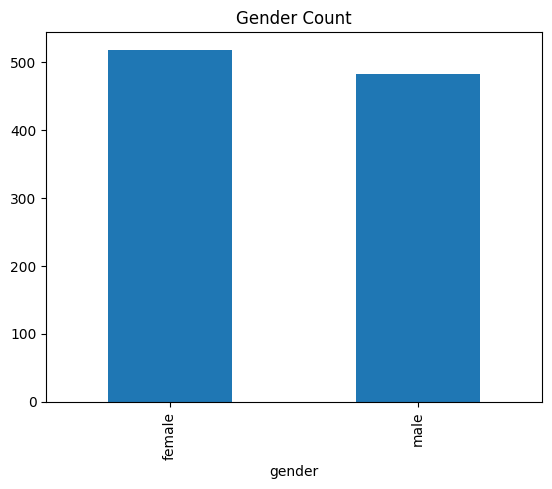

In [30]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Count")
plt.show()

In [31]:
df.groupby("gender")["average_score"].mean()

gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64

In [32]:
df.groupby("test_preparation_course")["average_score"].mean()

test_preparation_course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64

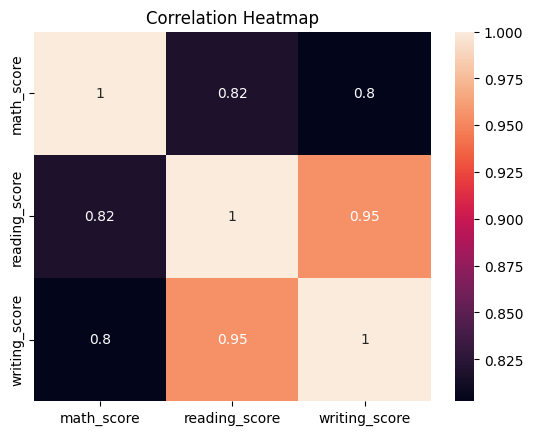

In [38]:
import seaborn as sns

sns.heatmap(df[["math_score", "reading_score", "writing_score"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Students who completed test prep scored higher

Reading & writing scores are strongly related

Most students are in mid score range

Parental education has some impact

In [34]:
from sklearn.model_selection import train_test_split

X = df[["math_score", "reading_score", "writing_score"]]
y = df["average_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
predictions = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, predictions)

4.867217739956687e-15